In [29]:

from pymysql import connect
import pandas as pd

import pandas as pd
import numpy as np
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats
from statsmodels.formula.api import ols
import statsmodels.api as sm

from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import RFECV

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score, confusion_matrix
import sklearn.metrics as metrics
from tabulate import tabulate

import warnings

warnings.filterwarnings("ignore")

In [2]:
database = connect(host = 'localhost', 
                  user = 'root',
                  password = 'Prajivinn@97',
                  database = 'capstone')

In [3]:
cur = database.cursor()

In [30]:
query = 'SELECT * FROM loan_application_details;'

cur.execute(query)

4269

In [31]:
df = pd.read_sql(query, database)

In [32]:
df.head()

,loan_id,no_of_dependents,gender,education,self_employed,income_annum,income_annum_group_lacs,loan_amount,loan_amount_group,loan_term,...,cibil_score_category,residential_assets_value,residential_assets_value_group,commercial_assets_value,commercial_assets_value_group,luxury_assets_value,luxury_assets_value_group,bank_asset_value,bank_asset_value_group,loan_status
0,1,2,Male,Post Graduate,No,9600000.0,90 Lacs+,29900000.0,2.5-3,12,...,Excellent,2400000.0,0-0.5,17600000.0,1.5-2,22700000.0,2-2.5,8000000.0,0.5-1,Approved
1,2,0,Male,Post Graduate,Yes,4100000.0,40-50 Lacs,12200000.0,1-1.5,8,...,Low,2700000.0,0-0.5,2200000.0,0-0.5,8800000.0,0.5-1,3300000.0,0-0.5,Rejected
2,3,3,Male,Post Graduate,No,9100000.0,90 Lacs+,29700000.0,2.5-3,20,...,Low,7100000.0,0.5-1,4500000.0,0-0.5,33300000.0,3-3.5,12800000.0,1-1.5,Rejected
3,4,3,Female,Post Graduate,No,8200000.0,80-90 Lacs,30700000.0,3-3.5,8,...,Low,18200000.0,1.5-2,3300000.0,0-0.5,23300000.0,2-2.5,7900000.0,0.5-1,Rejected
4,5,5,Male,Post Graduate,Yes,9800000.0,90 Lacs+,24200000.0,2-2.5,20,...,Low,12400000.0,1-1.5,8200000.0,0.5-1,29400000.0,2.5-3,5000000.0,0.5-1,Rejected


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   loan_id                         4269 non-null   int64  
 1   no_of_dependents                4269 non-null   int64  
 2   gender                          4269 non-null   object 
 3   education                       4269 non-null   object 
 4   self_employed                   4269 non-null   object 
 5   income_annum                    4269 non-null   float64
 6   income_annum_group_lacs         4269 non-null   object 
 7   loan_amount                     4269 non-null   float64
 8   loan_amount_group               4269 non-null   object 
 9   loan_term                       4269 non-null   int64  
 10  cibil_score                     4269 non-null   int64  
 11  cibil_score_category            4269 non-null   object 
 12  residential_assets_value        42

In [34]:
df.isna().sum()

loan_id                           0
no_of_dependents                  0
gender                            0
education                         0
self_employed                     0
income_annum                      0
income_annum_group_lacs           0
loan_amount                       0
loan_amount_group                 0
loan_term                         0
cibil_score                       0
cibil_score_category              0
residential_assets_value          0
residential_assets_value_group    0
commercial_assets_value           0
commercial_assets_value_group     0
luxury_assets_value               0
luxury_assets_value_group         0
bank_asset_value                  0
bank_asset_value_group            0
loan_status                       0
dtype: int64

There are no null values present in the dataset.

In [35]:
df["loan_status"].value_counts(normalize = True)

loan_status
Approved    0.62216
Rejected    0.37784
Name: proportion, dtype: float64

We see that 62% of customers got their loan approved and 37% got rejected. This tells us that while the data isn’t perfectly balanced at 50:50, it isn’t too imbalanced either. Because of this, and as you will see, we make sure to not rely on classification accuracy alone when assessing results - also analysing Precision, Recall, and F1-Score.

### Exploratory Data Analysis

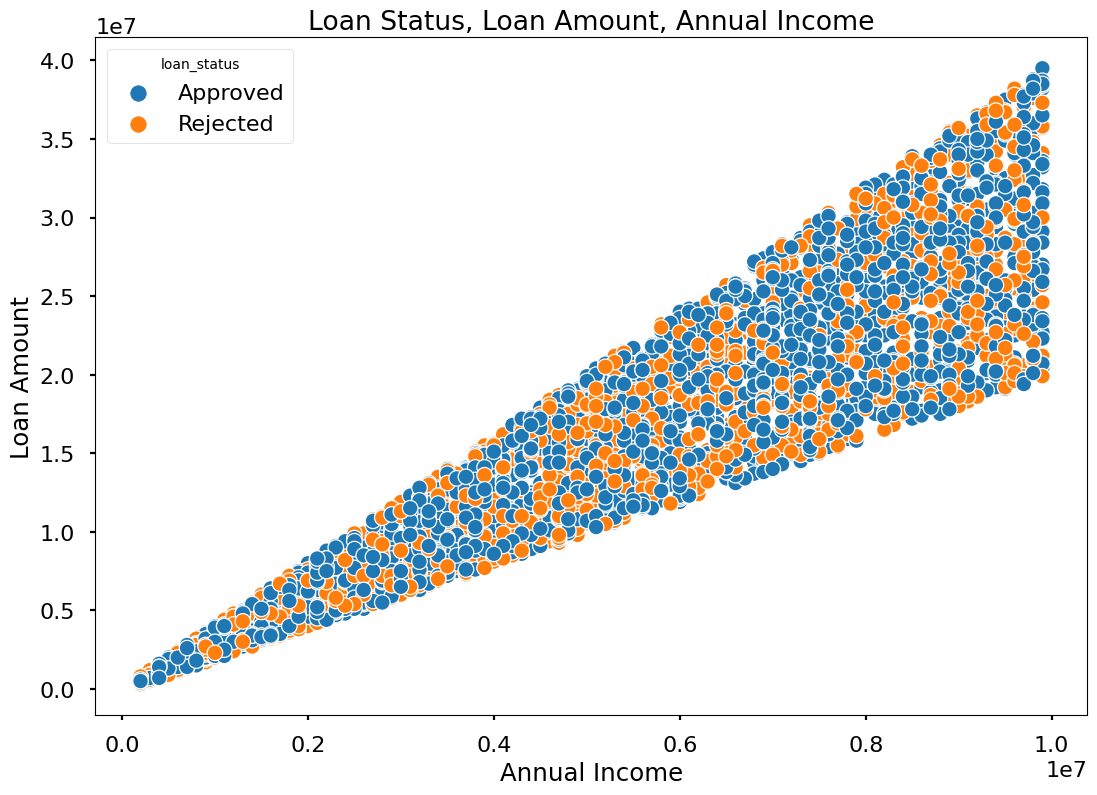

In [324]:
sns.scatterplot(x=df['income_annum'], y= df['loan_amount'], hue=df['loan_status'])
plt.title("Loan Status, Loan Amount, Annual Income")
plt.xlabel("Annual Income")
plt.ylabel("Loan Amount")
plt.savefig('CP_1.jpg',bbox_inches='tight',dpi=150)
plt.show()

As annual income rises, there is a tendency for the loan amount requested to increase. Notably, even among applicants with the highest annual incomes, some were approved for the highest loan amounts, while others faced rejections. This suggests that loan approval for a specific loan amount is not solely contingent on annual income.

Let's look at the asset value variables. we will create a subset and get to know the correlation scores between those 4 asset values and other variables.

In [325]:
loan_asset_variables = df[['residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'no_of_dependents',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score']]
loan_asset_variables_corr = loan_asset_variables.corr()

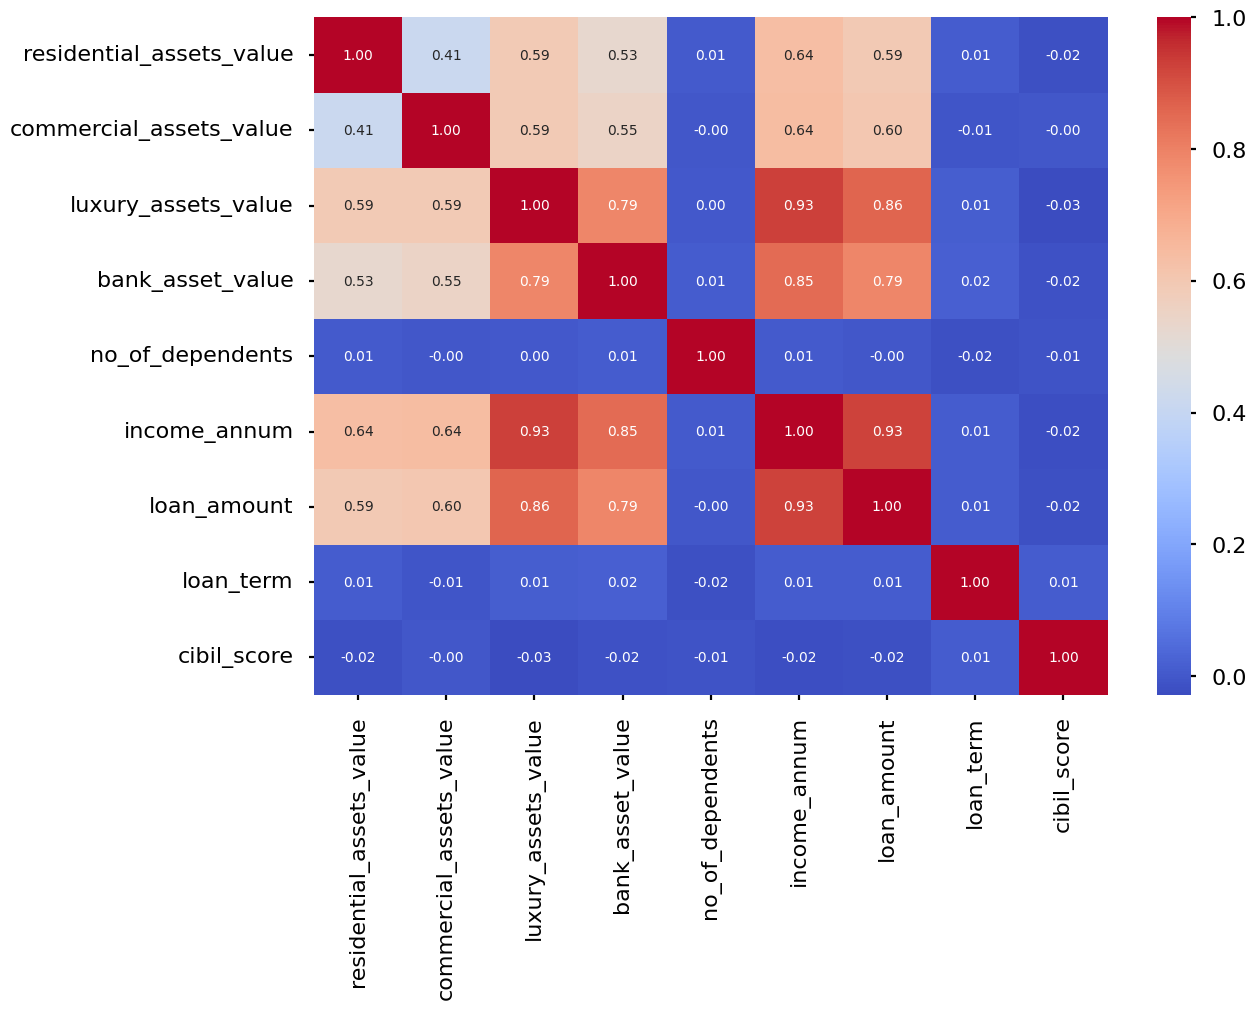

In [326]:
sns.heatmap(loan_asset_variables_corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.savefig('CP_2.jpg',bbox_inches='tight',dpi=150)

The asset values exhibit moderate to strong positive linear associations with annual income. Applicants with higher annual incomes tend to have greater purchasing power, particularly when it comes to properties with higher asset values, including luxury assets.

In [327]:
loan_term = pd.crosstab(index=df['loan_term'], columns=df['loan_status'])
loan_term['Total'] = loan_term['Approved'] + loan_term['Rejected'] 
loan_term['Approved_percentage'] = (loan_term['Approved']/loan_term['Total'])*100
loan_term['Rejected_percentage'] = (loan_term['Rejected']/loan_term['Total'])*100
loan_term

loan_status,Approved,Rejected,Total,Approved_percentage,Rejected_percentage
loan_term,,,,,
2,315,89,404,77.970297,22.029703
4,366,81,447,81.879195,18.120805
6,282,208,490,57.551020,42.448980
8,220,166,386,56.994819,43.005181
10,229,207,436,52.522936,47.477064
12,276,180,456,60.526316,39.473684
14,239,166,405,59.012346,40.987654
16,236,176,412,57.281553,42.718447
18,257,165,422,60.900474,39.099526


* It's evident that shorter loan terms, such as 4, 6, and 8 years, have significantly higher approval percentages (above 56%) compared to longer terms.
* The 4-year term has the highest approval percentage, at 81.88%, suggesting that customers prefer shorter loan durations, possibly due to reduced interest costs.
* Conversely, longer loan terms like 10, 12, and 14 years have higher rejection percentages, with the 14-year term having the highest at 40.99%.
* This implies that customers are more likely to be rejected for loans with longer durations, possibly due to increased credit risk.
* Despite varying approval and rejection percentages, the total number of applications remains relatively consistent, hovering around 400 to 450 applications for most loan terms.

### Building Classification Model

In [36]:
df.columns

Index(['loan_id', 'no_of_dependents', 'gender', 'education', 'self_employed',
       'income_annum', 'income_annum_group_lacs', 'loan_amount',
       'loan_amount_group', 'loan_term', 'cibil_score', 'cibil_score_category',
       'residential_assets_value', 'residential_assets_value_group',
       'commercial_assets_value', 'commercial_assets_value_group',
       'luxury_assets_value', 'luxury_assets_value_group', 'bank_asset_value',
       'bank_asset_value_group', 'loan_status'],
      dtype='object')

In [37]:
df_model = df[['no_of_dependents', 'gender', 'education', 'self_employed','income_annum', 'loan_amount',     
               'loan_term', 'cibil_score','residential_assets_value','commercial_assets_value', 
               'luxury_assets_value',  'bank_asset_value', 'loan_status']]

In [38]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   no_of_dependents          4269 non-null   int64  
 1   gender                    4269 non-null   object 
 2   education                 4269 non-null   object 
 3   self_employed             4269 non-null   object 
 4   income_annum              4269 non-null   float64
 5   loan_amount               4269 non-null   float64
 6   loan_term                 4269 non-null   int64  
 7   cibil_score               4269 non-null   int64  
 8   residential_assets_value  4269 non-null   float64
 9   commercial_assets_value   4269 non-null   float64
 10  luxury_assets_value       4269 non-null   float64
 11  bank_asset_value          4269 non-null   float64
 12  loan_status               4269 non-null   object 
dtypes: float64(6), int64(3), object(4)
memory usage: 433.7+ KB


In [39]:
df_model["loan_status"]= df_model["loan_status"].map({"Approved":1,"Rejected":0})

In [40]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   no_of_dependents          4269 non-null   int64  
 1   gender                    4269 non-null   object 
 2   education                 4269 non-null   object 
 3   self_employed             4269 non-null   object 
 4   income_annum              4269 non-null   float64
 5   loan_amount               4269 non-null   float64
 6   loan_term                 4269 non-null   int64  
 7   cibil_score               4269 non-null   int64  
 8   residential_assets_value  4269 non-null   float64
 9   commercial_assets_value   4269 non-null   float64
 10  luxury_assets_value       4269 non-null   float64
 11  bank_asset_value          4269 non-null   float64
 12  loan_status               4269 non-null   int64  
dtypes: float64(6), int64(4), object(3)
memory usage: 433.7+ KB


**Split Out Data For Modelling**

In the next code block we do two things, we firstly split our data into an X object which contains only the predictor variables, and a y object that contains only our dependent variable.

Once we have done this, we split our data into training and test sets to ensure we can fairly validate the accuracy of the predictions on data that was not used in training. In this case, we have allocated 80% of the data for training, and the remaining 20% for validation. We make sure to add in the stratify parameter to ensure that both our training and test sets have the same proportion of customers who got approved and rejected of the loan - meaning we can be more confident in our assessment of predictive performance.

In [41]:
# split data into X and y objects for modelling
X = df_model.drop(["loan_status"], axis = 1)
y = df_model["loan_status"]

# split out training & test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(3415, 12)
(854, 12)
(3415,)
(854,)


In [42]:
# list of categorical variables that need encoding
categorical_vars = ["gender","education", "self_employed"]

# instantiate OHE class
one_hot_encoder = OneHotEncoder(sparse=False, drop = "first")

# apply OHE
X_train_encoded = one_hot_encoder.fit_transform(X_train[categorical_vars])
X_test_encoded = one_hot_encoder.transform(X_test[categorical_vars])

# extract feature names for encoded columns
encoder_feature_names = one_hot_encoder.get_feature_names_out(categorical_vars)

# turn objects back to pandas dataframe
X_train_encoded = pd.DataFrame(X_train_encoded, columns = encoder_feature_names)
X_train = pd.concat([X_train.reset_index(drop=True), X_train_encoded.reset_index(drop=True)], axis = 1)
X_train.drop(categorical_vars, axis = 1, inplace = True)

X_test_encoded = pd.DataFrame(X_test_encoded, columns = encoder_feature_names)
X_test = pd.concat([X_test.reset_index(drop=True), X_test_encoded.reset_index(drop=True)], axis = 1)
X_test.drop(categorical_vars, axis = 1, inplace = True)

In [335]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3415 entries, 0 to 3414
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   no_of_dependents          3415 non-null   int64  
 1   income_annum              3415 non-null   float64
 2   loan_amount               3415 non-null   float64
 3   loan_term                 3415 non-null   int64  
 4   cibil_score               3415 non-null   int64  
 5   residential_assets_value  3415 non-null   float64
 6   commercial_assets_value   3415 non-null   float64
 7   luxury_assets_value       3415 non-null   float64
 8   bank_asset_value          3415 non-null   float64
 9   gender_Male               3415 non-null   float64
 10  education_Not Graduate    3415 non-null   float64
 11  education_Post Graduate   3415 non-null   float64
 12  self_employed_Yes         3415 non-null   float64
dtypes: float64(10), int64(3)
memory usage: 347.0 KB


In [43]:

# create our standardscaler object
scale_stand = StandardScaler()

# normalise the training set (using fit_transform)
X_train = pd.DataFrame(scale_stand.fit_transform(X_train), columns = X_train.columns)

# normalise the test set (using transform only)
X_test = pd.DataFrame(scale_stand.transform(X_test), columns = X_test.columns)

In [44]:

# instantiate RFECV & the model type to be utilised
clf = LogisticRegression(random_state = 42, max_iter = 1000)
feature_selector = RFECV(clf)

# fit RFECV onto our training & test data
fit = feature_selector.fit(X_train,y_train)

# extract & print the optimal number of features
optimal_feature_count = feature_selector.n_features_
print(f"Optimal number of features: {optimal_feature_count}")

# limit our training & test sets to only include the selected variables
X_train_features = X_train.loc[:, feature_selector.get_support()]
X_test_features = X_test.loc[:, feature_selector.get_support()]

Optimal number of features: 3


In [45]:
X_train_features.columns

Index(['income_annum', 'loan_amount', 'cibil_score'], dtype='object')

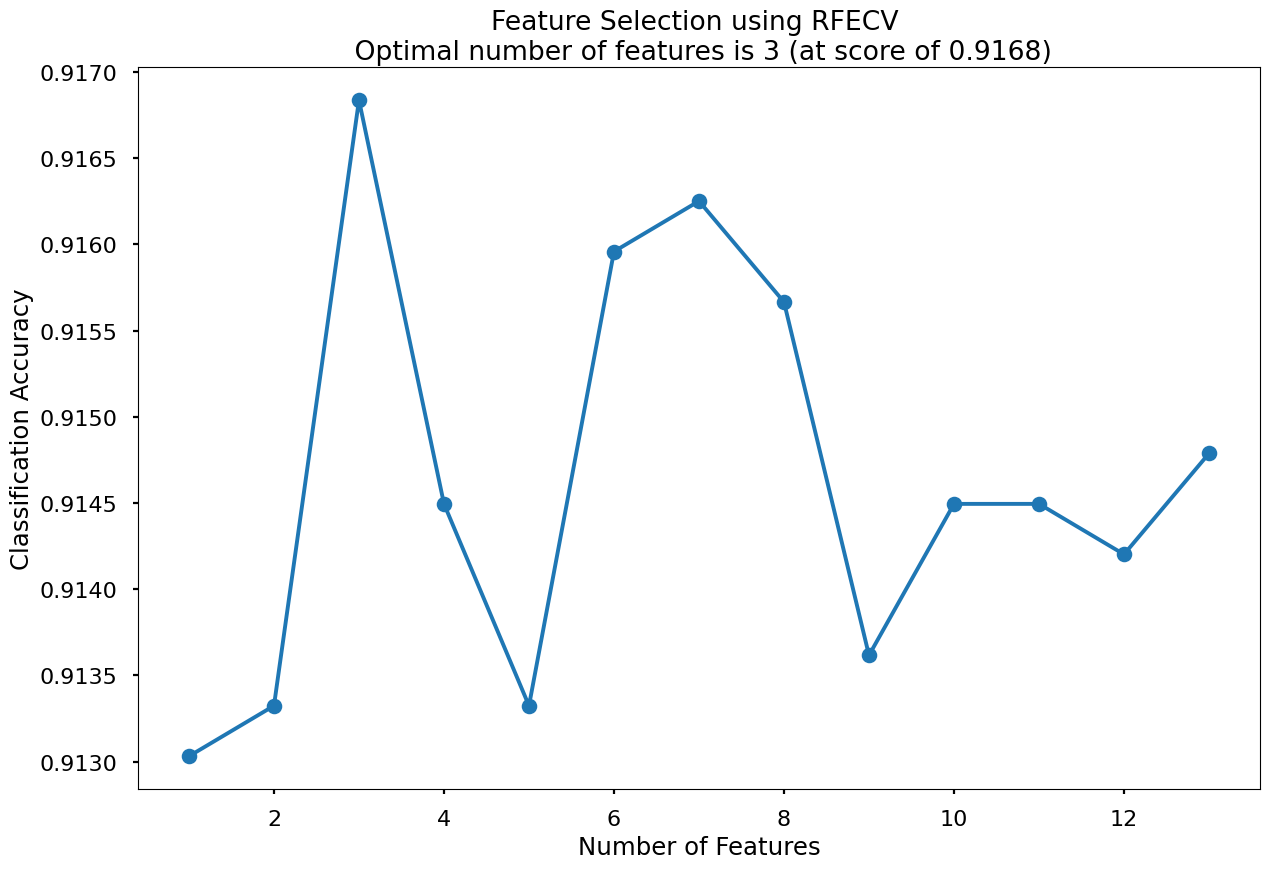

In [340]:

plt.style.use('seaborn-poster')
plt.plot(range(1, len(fit.cv_results_['mean_test_score']) + 1), fit.cv_results_['mean_test_score'], marker = "o")
plt.ylabel("Classification Accuracy")
plt.xlabel("Number of Features")
plt.title(f"Feature Selection using RFECV \n Optimal number of features is {optimal_feature_count} (at score of {round(max(fit.cv_results_['mean_test_score']),4)})")
plt.tight_layout()
plt.savefig('CP_3.jpg',bbox_inches='tight',dpi=150)
plt.show()

In [46]:
clf = LogisticRegression(random_state = 42, max_iter = 1000)

# fit our model using our training & test sets
clf.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [47]:
# predict on the test set
y_pred_class = clf.predict(X_test)
y_pred_prob = clf.predict_proba(X_test)[:,1]

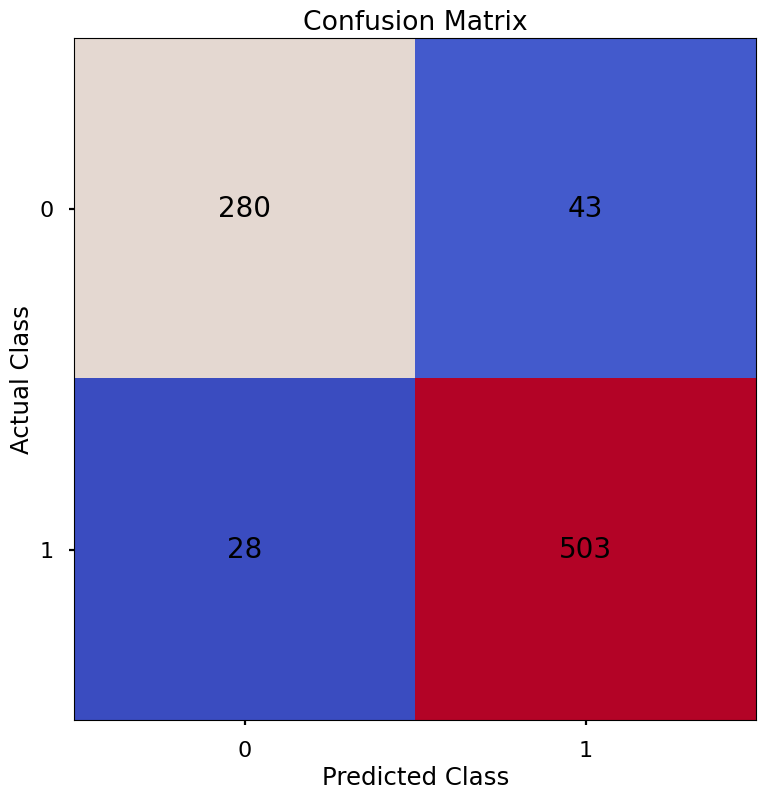

In [343]:
# create the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_class)

# plot the confusion matrix
plt.style.use("seaborn-poster")
plt.matshow(conf_matrix, cmap = "coolwarm")
plt.gca().xaxis.tick_bottom()
plt.title("Confusion Matrix")
plt.ylabel("Actual Class")
plt.xlabel("Predicted Class")
for (i, j), corr_value in np.ndenumerate(conf_matrix):
    plt.text(j, i, corr_value, ha = "center", va = "center", fontsize = 20)

plt.savefig('CP_4.jpg',bbox_inches='tight',dpi=150)
plt.show()

In [48]:
print('Accuracy:', '%.3f' % accuracy_score(y_test, y_pred_class))
print('Precision:', '%.3f' % precision_score(y_test, y_pred_class))
print('Recall:', '%.3f' % recall_score(y_test, y_pred_class))
print('F1 Score:', '%.3f' % f1_score(y_test, y_pred_class))

Accuracy: 0.917
Precision: 0.921
Recall: 0.947
F1 Score: 0.934


The scores in the confusion matrix above mean:

* True negatives (upper left)  : The number of applications that were rejected that the model accurately predicted were rejected.
* False negatives (bottom left): The number of applications that were approved that the model inaccurately predicted were rejected.
* False positives (upper right): The number of applications that were rejected that the model inaccurately predicted were approved.
* True positives (bottom right): The number of applications that were approved that the model accurately predicted were approved.

In [51]:
clf.coef_[0]

array([-0.06459921, -1.62672228,  1.36855315, -0.84697244,  4.08189545,
        0.03525499,  0.06828631,  0.13481621,  0.17299408,  0.0119762 ,
        0.02629256, -0.3856379 ,  0.00679072])

In [53]:
X_train.columns

Index(['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term',
       'cibil_score', 'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'gender_Male',
       'education_Not Graduate', 'education_Post Graduate',
       'self_employed_Yes'],
      dtype='object')

In [52]:
feature_names = X.columns if isinstance(X, pd.DataFrame) else np.arange(X.shape[1])
feature_names

Index(['no_of_dependents', 'gender', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value'],
      dtype='object')

In [55]:
# Get feature names (if using a DataFrame)
feature_names = X_train.columns if isinstance(X_train, pd.DataFrame) else np.arange(X_train.shape[1])

# Create a DataFrame to store feature names and their coefficients
feature_importance = pd.DataFrame({'Feature': feature_names, 'Coefficient': clf.coef_[0]})

# Sort by absolute coefficient values in descending order to find the most important features
feature_importance['Absolute_Coefficient'] = np.abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values(by='Absolute_Coefficient', ascending=False)

# Print or visualize the most important features
print(feature_importance)

                     Feature  Coefficient  Absolute_Coefficient
4                cibil_score     4.081895              4.081895
1               income_annum    -1.626722              1.626722
2                loan_amount     1.368553              1.368553
3                  loan_term    -0.846972              0.846972
11   education_Post Graduate    -0.385638              0.385638
8           bank_asset_value     0.172994              0.172994
7        luxury_assets_value     0.134816              0.134816
6    commercial_assets_value     0.068286              0.068286
0           no_of_dependents    -0.064599              0.064599
5   residential_assets_value     0.035255              0.035255
10    education_Not Graduate     0.026293              0.026293
9                gender_Male     0.011976              0.011976
12         self_employed_Yes     0.006791              0.006791


In [348]:
# set up the list of thresholds to loop through
thresholds = np.arange(0, 1, 0.01)

# create empty lists to append the results to
precision_scores = []
recall_scores = []
f1_scores = []

# loop through each threshold - fit the model - append the results
for threshold in thresholds:
    
    pred_class = (y_pred_prob >= threshold) * 1
    
    precision = precision_score(y_test, pred_class, zero_division = 0)
    precision_scores.append(precision)
    
    recall = recall_score(y_test, pred_class)
    recall_scores.append(recall)
    
    f1 = f1_score(y_test, pred_class)
    f1_scores.append(f1)
    
# extract the optimal f1-score (and it's index)
max_f1 = max(f1_scores)
max_f1_idx = f1_scores.index(max_f1)

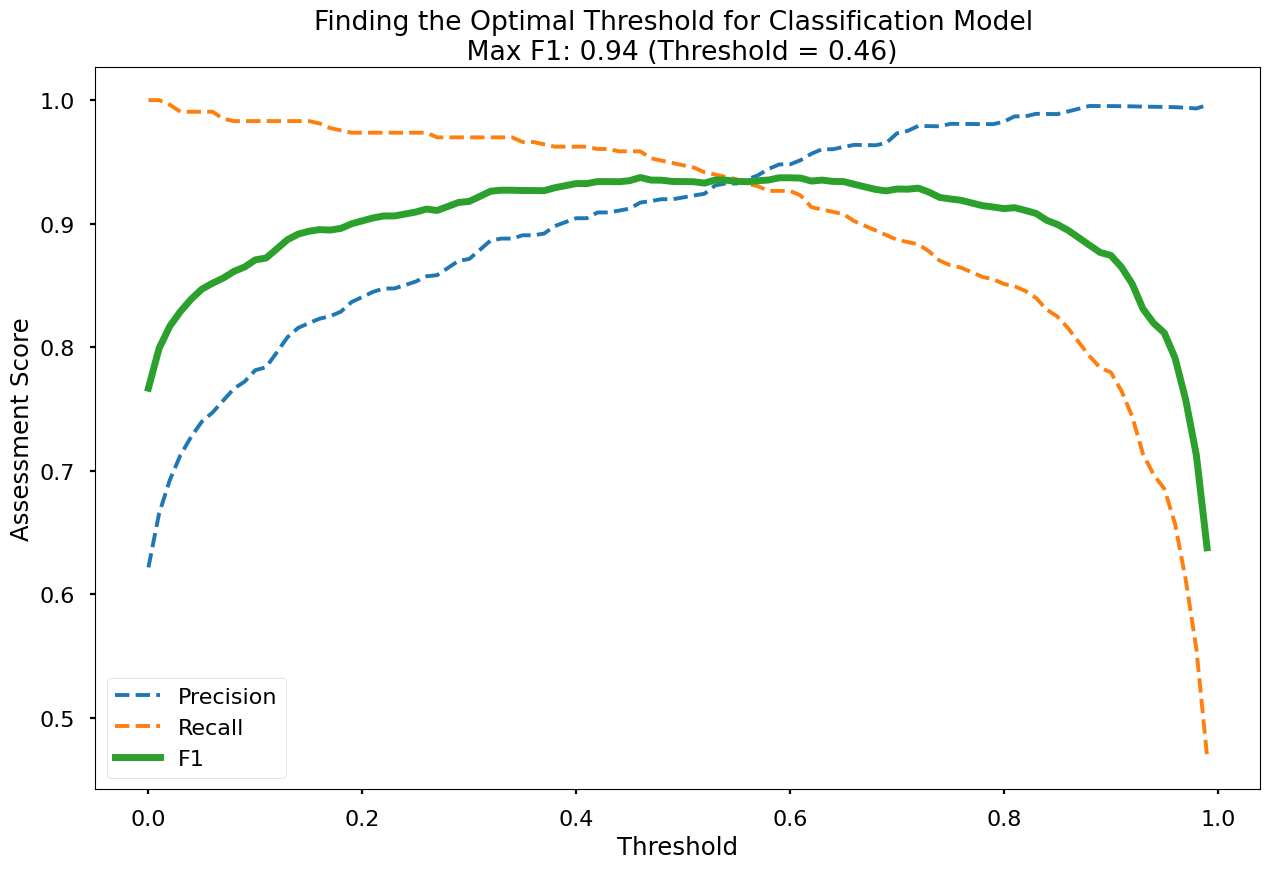

In [349]:
# plot the results
plt.style.use("seaborn-poster")
plt.plot(thresholds, precision_scores, label = "Precision", linestyle = "--")
plt.plot(thresholds, recall_scores, label = "Recall", linestyle = "--")
plt.plot(thresholds, f1_scores, label = "F1", linewidth = 5)
plt.title(f"Finding the Optimal Threshold for Classification Model \n Max F1: {round(max_f1,2)} (Threshold = {round(thresholds[max_f1_idx],2)})")
plt.xlabel("Threshold")
plt.ylabel("Assessment Score")
plt.legend(loc = "lower left")
plt.tight_layout()
plt.savefig('CP_5.jpg',bbox_inches='tight',dpi=150)
plt.show()

Along the x-axis of the above plot we have the different classification thresholds that were testing. Along the y-axis we have the performance score for each of our three metrics. As per the legend, we have Precision as a blue dotted line, Recall as an orange dotted line, and F1-Score as a thick green line. You can see the interesting “zero-sum” relationship between Precision & Recall and you can see that the point where Precision & Recall meet is where F1-Score is maximised.

As you can see at the top of the plot, the optimal F1-Score for this model 0.94 and this is obtained at a classification threshold of 0.46. This is higher than the F1-Score of 0.934 that we achieved at the default classification threshold of 0.50!

In [350]:
optimal_threshold = 0.46
y_pred_class_opt_thresh = (y_pred_prob >= optimal_threshold) * 1
y_pred_class_opt_thresh

array([1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,

Overall this model performed pretty well with f1-score of **94%** being reached when we altered our
probability threshold classification

## Decision Tree
We will again utlise the scikit-learn library within Python to model our data using a Decision Tree. The code sections below are broken up into 6 key sections:

* Data Import
* Data Preprocessing
* Model Training
* Performance Assessment
* Tree Visualisation
* Decision Tree Regularisation

In [403]:
# import required packages
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import OneHotEncoder

In [404]:
df = pd.read_sql(query, database)

In [405]:
df.head()

,loan_id,no_of_dependents,gender,education,self_employed,income_annum,income_annum_group_lacs,loan_amount,loan_amount_group,loan_term,...,cibil_score_category,residential_assets_value,residential_assets_value_group,commercial_assets_value,commercial_assets_value_group,luxury_assets_value,luxury_assets_value_group,bank_asset_value,bank_asset_value_group,loan_status
0,1,2,Male,Post Graduate,No,9600000.0,90 Lacs+,29900000.0,2.5-3,12,...,Excellent,2400000.0,0-0.5,17600000.0,1.5-2,22700000.0,2-2.5,8000000.0,0.5-1,Approved
1,2,0,Male,Post Graduate,Yes,4100000.0,40-50 Lacs,12200000.0,1-1.5,8,...,Low,2700000.0,0-0.5,2200000.0,0-0.5,8800000.0,0.5-1,3300000.0,0-0.5,Rejected
2,3,3,Male,Post Graduate,No,9100000.0,90 Lacs+,29700000.0,2.5-3,20,...,Low,7100000.0,0.5-1,4500000.0,0-0.5,33300000.0,3-3.5,12800000.0,1-1.5,Rejected
3,4,3,Female,Post Graduate,No,8200000.0,80-90 Lacs,30700000.0,3-3.5,8,...,Low,18200000.0,1.5-2,3300000.0,0-0.5,23300000.0,2-2.5,7900000.0,0.5-1,Rejected
4,5,5,Male,Post Graduate,Yes,9800000.0,90 Lacs+,24200000.0,2-2.5,20,...,Low,12400000.0,1-1.5,8200000.0,0.5-1,29400000.0,2.5-3,5000000.0,0.5-1,Rejected


In [406]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   loan_id                         4269 non-null   int64  
 1   no_of_dependents                4269 non-null   int64  
 2   gender                          4269 non-null   object 
 3   education                       4269 non-null   object 
 4   self_employed                   4269 non-null   object 
 5   income_annum                    4269 non-null   float64
 6   income_annum_group_lacs         4269 non-null   object 
 7   loan_amount                     4269 non-null   float64
 8   loan_amount_group               4269 non-null   object 
 9   loan_term                       4269 non-null   int64  
 10  cibil_score                     4269 non-null   int64  
 11  cibil_score_category            4269 non-null   object 
 12  residential_assets_value        42

In [407]:
df["loan_status"].value_counts(normalize = True)

loan_status
Approved    0.62216
Rejected    0.37784
Name: proportion, dtype: float64

In [408]:
df.columns

Index(['loan_id', 'no_of_dependents', 'gender', 'education', 'self_employed',
       'income_annum', 'income_annum_group_lacs', 'loan_amount',
       'loan_amount_group', 'loan_term', 'cibil_score', 'cibil_score_category',
       'residential_assets_value', 'residential_assets_value_group',
       'commercial_assets_value', 'commercial_assets_value_group',
       'luxury_assets_value', 'luxury_assets_value_group', 'bank_asset_value',
       'bank_asset_value_group', 'loan_status'],
      dtype='object')

In [409]:
df_model = df[['no_of_dependents', 'gender', 'education', 'self_employed','income_annum', 'loan_amount',     
               'loan_term', 'cibil_score','residential_assets_value','commercial_assets_value', 
               'luxury_assets_value',  'bank_asset_value', 'loan_status']]

In [410]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   no_of_dependents          4269 non-null   int64  
 1   gender                    4269 non-null   object 
 2   education                 4269 non-null   object 
 3   self_employed             4269 non-null   object 
 4   income_annum              4269 non-null   float64
 5   loan_amount               4269 non-null   float64
 6   loan_term                 4269 non-null   int64  
 7   cibil_score               4269 non-null   int64  
 8   residential_assets_value  4269 non-null   float64
 9   commercial_assets_value   4269 non-null   float64
 10  luxury_assets_value       4269 non-null   float64
 11  bank_asset_value          4269 non-null   float64
 12  loan_status               4269 non-null   object 
dtypes: float64(6), int64(3), object(4)
memory usage: 433.7+ KB


In [411]:
df_model["loan_status"]= df_model["loan_status"].map({"Approved":1,"Rejected":0})

In [412]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   no_of_dependents          4269 non-null   int64  
 1   gender                    4269 non-null   object 
 2   education                 4269 non-null   object 
 3   self_employed             4269 non-null   object 
 4   income_annum              4269 non-null   float64
 5   loan_amount               4269 non-null   float64
 6   loan_term                 4269 non-null   int64  
 7   cibil_score               4269 non-null   int64  
 8   residential_assets_value  4269 non-null   float64
 9   commercial_assets_value   4269 non-null   float64
 10  luxury_assets_value       4269 non-null   float64
 11  bank_asset_value          4269 non-null   float64
 12  loan_status               4269 non-null   int64  
dtypes: float64(6), int64(4), object(3)
memory usage: 433.7+ KB


In [413]:
# split data into X and y objects for modelling
X = df_model.drop(["loan_status"], axis = 1)
y = df_model["loan_status"]

# split out training & test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [414]:
# list of categorical variables that need encoding
categorical_vars = ["gender","education", "self_employed"]

# instantiate OHE class
one_hot_encoder = OneHotEncoder(sparse=False, drop = "first")

# apply OHE
X_train_encoded = one_hot_encoder.fit_transform(X_train[categorical_vars])
X_test_encoded = one_hot_encoder.transform(X_test[categorical_vars])

# extract feature names for encoded columns
encoder_feature_names = one_hot_encoder.get_feature_names_out(categorical_vars)

# turn objects back to pandas dataframe
X_train_encoded = pd.DataFrame(X_train_encoded, columns = encoder_feature_names)
X_train = pd.concat([X_train.reset_index(drop=True), X_train_encoded.reset_index(drop=True)], axis = 1)
X_train.drop(categorical_vars, axis = 1, inplace = True)

X_test_encoded = pd.DataFrame(X_test_encoded, columns = encoder_feature_names)
X_test = pd.concat([X_test.reset_index(drop=True), X_test_encoded.reset_index(drop=True)], axis = 1)
X_test.drop(categorical_vars, axis = 1, inplace = True)

In [415]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3415 entries, 0 to 3414
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   no_of_dependents          3415 non-null   int64  
 1   income_annum              3415 non-null   float64
 2   loan_amount               3415 non-null   float64
 3   loan_term                 3415 non-null   int64  
 4   cibil_score               3415 non-null   int64  
 5   residential_assets_value  3415 non-null   float64
 6   commercial_assets_value   3415 non-null   float64
 7   luxury_assets_value       3415 non-null   float64
 8   bank_asset_value          3415 non-null   float64
 9   gender_Male               3415 non-null   float64
 10  education_Not Graduate    3415 non-null   float64
 11  education_Post Graduate   3415 non-null   float64
 12  self_employed_Yes         3415 non-null   float64
dtypes: float64(10), int64(3)
memory usage: 347.0 KB


In [416]:

# instantiate our model object
dt = DecisionTreeClassifier(random_state = 42, max_depth = 5)

# fit our model using our training & test sets
dt.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5, random_state=42)

In [417]:
# predict on the test set
y_pred_class = dt.predict(X_test)
y_pred_prob = dt.predict_proba(X_test)[:,1]

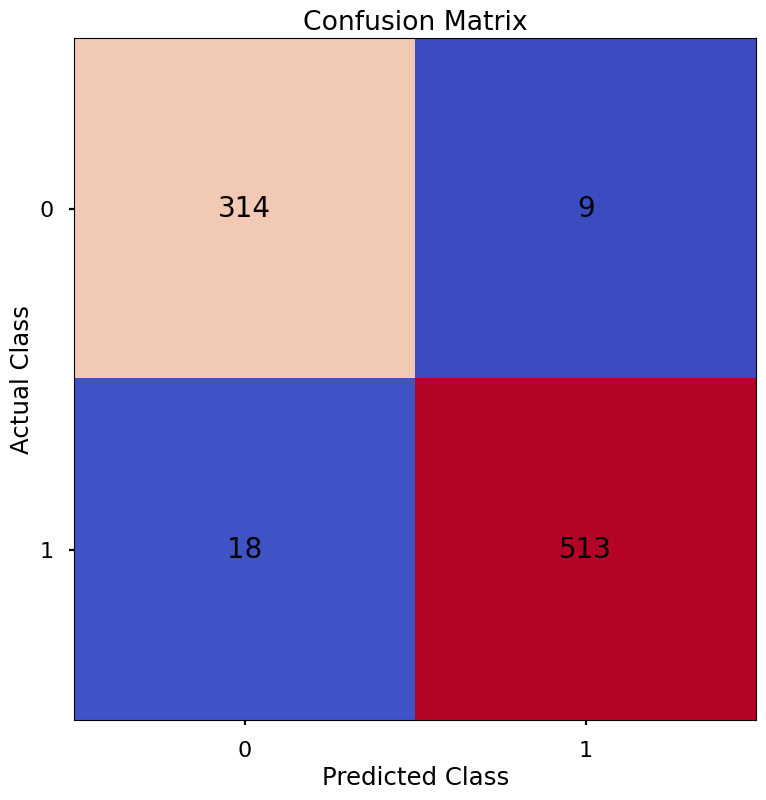

In [418]:

# create the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_class)

# plot the confusion matrix
plt.style.use("seaborn-poster")
plt.matshow(conf_matrix, cmap = "coolwarm")
plt.gca().xaxis.tick_bottom()
plt.title("Confusion Matrix")
plt.ylabel("Actual Class")
plt.xlabel("Predicted Class")
for (i, j), corr_value in np.ndenumerate(conf_matrix):
    plt.text(j, i, corr_value, ha = "center", va = "center", fontsize = 20)

plt.savefig('CP_6.jpg',bbox_inches='tight',dpi=150)
plt.show()

The aim is to have a high proportion of observations falling into the top left cell (predicted rejected and actual rejected) and the bottom right cell (predicted approved and actual approved).

Since the proportion of signups in our data was around 30:70 we will again analyse not only Classification Accuracy, but also Precision, Recall, and F1-Score as they will help us assess how well our model has performed from different points of view.

In [419]:
print('Accuracy:', '%.3f' % accuracy_score(y_test, y_pred_class))
print('Precision:', '%.3f' % precision_score(y_test, y_pred_class))
print('Recall:', '%.3f' % recall_score(y_test, y_pred_class))
print('F1 Score:', '%.3f' % f1_score(y_test, y_pred_class))

Accuracy: 0.968
Precision: 0.983
Recall: 0.966
F1 Score: 0.974


* Accuracy: We have an accuracy of around 0.968. This suggests that our model is correctly classifying around 90.9% of instances.

* Precision: Precision measures how many of the predicted positive instances are actually positive. With a precision of around 0.983, it means that about 98.3% of the instances predicted as positive by our model are truly positive.

* Recall: Recall, also known as sensitivity or true positive rate, indicates how many of the actual positive instances our model is capturing. With a recall of around 0.966, it means that our model is correctly identifying about 96.6% of the actual positive instances.

* F1 Score: The F1 score is the harmonic mean of precision and recall and provides a balanced view of a model's performance. With an F1 score of around 0.974, it indicates that the model is achieving a balanced trade-off between precision and recall.

**Visualise Our Decision Tree**

To see the decisions that have been made in the tree, we can use the plot_tree functionality that we imported from scikit-learn. To do this, we use the below code:

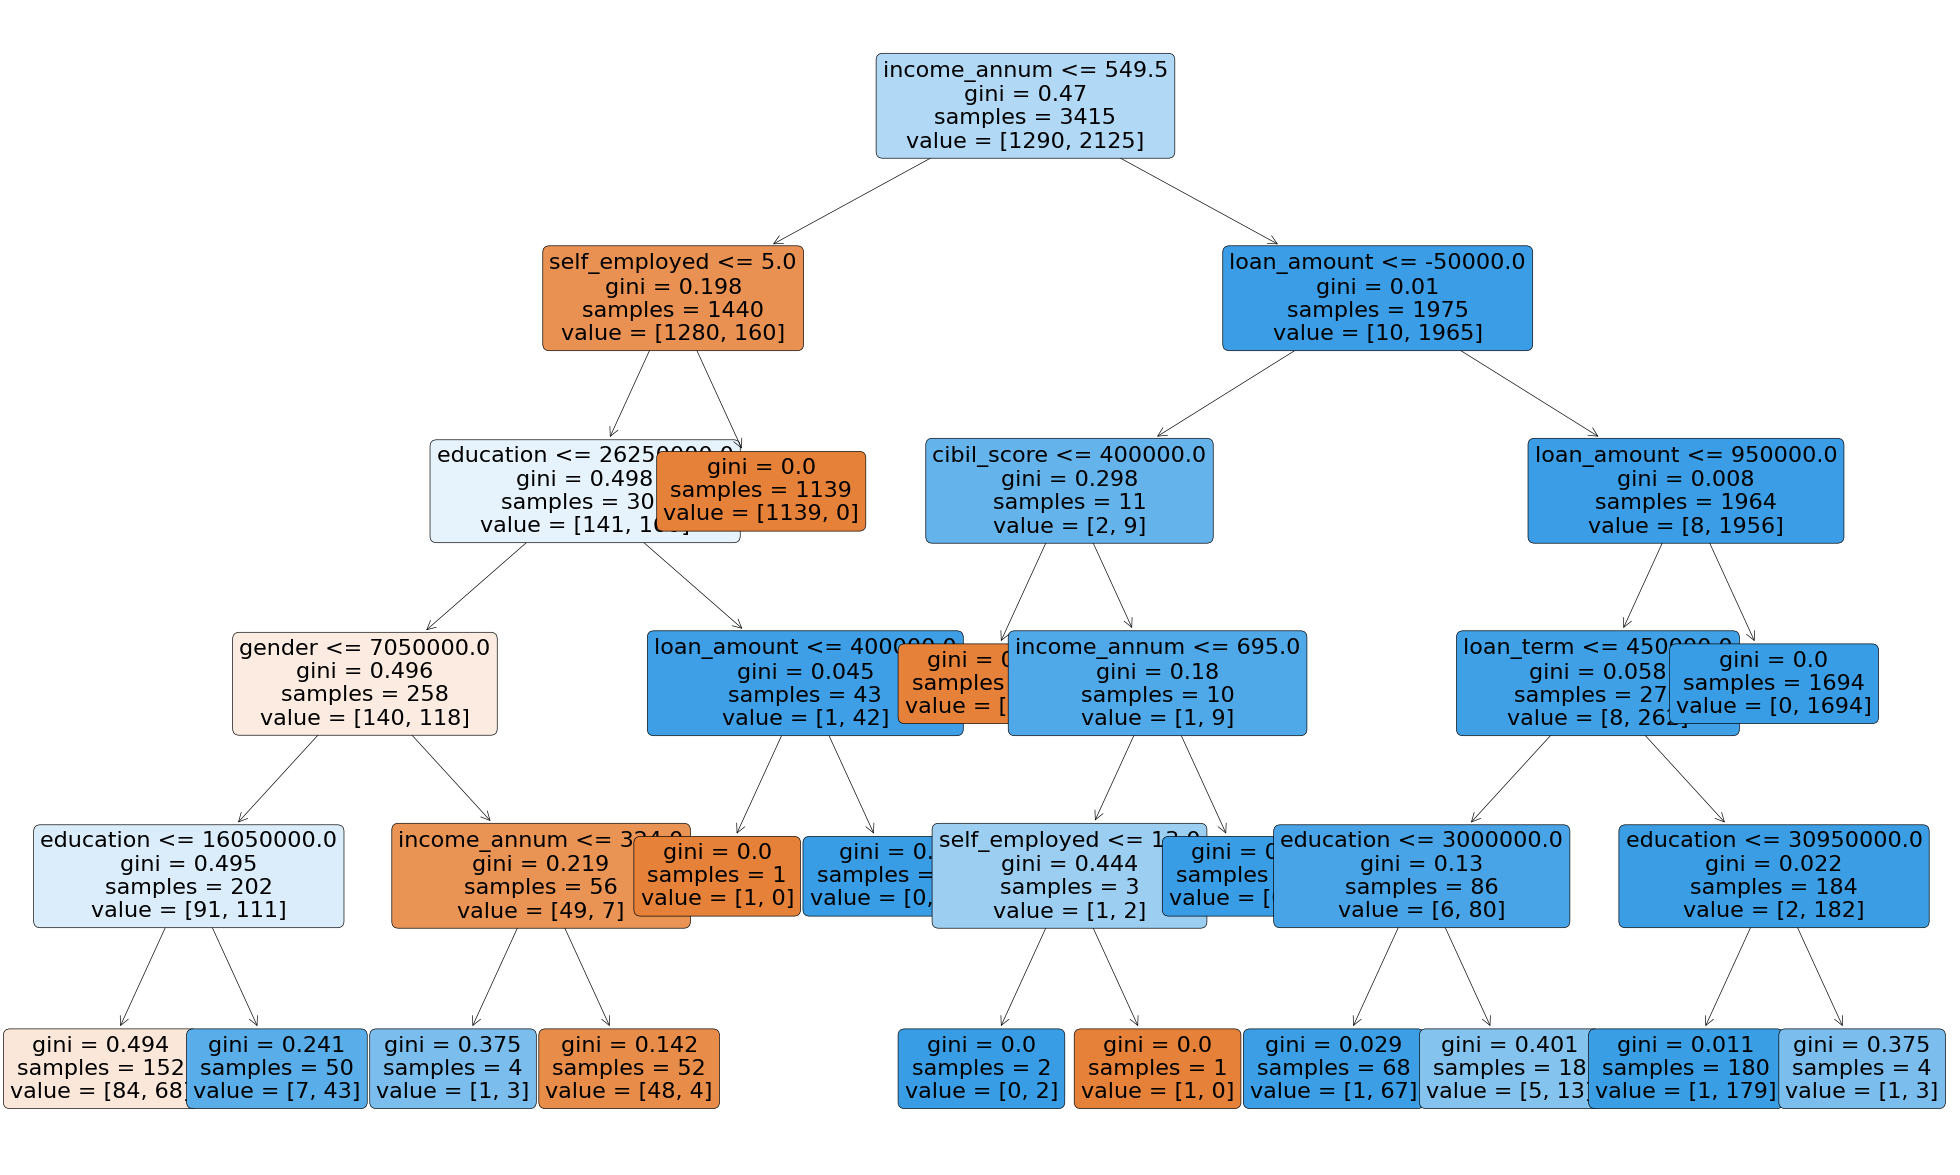

In [420]:
# plot the nodes of the decision tree
plt.figure(figsize=(25,15))
tree = plot_tree(dt,
                 feature_names = X.columns,
                 filled = True,
                 rounded = True,
                 fontsize = 16)
plt.savefig('CP_7.jpg',bbox_inches='tight',dpi=150)

This is a very powerful visual, and one that can be shown to stakeholders in the business to ensure they understand exactly what is driving the predictions.

One interesting thing to note is that the very first split appears to be using the variable **income_annum** so it would seem that this is a very important variable when it comes to predicting loan status

**Decision Tree Regularisation**

Decision Tree’s can be prone to over-fitting, in other words, without any limits on their splitting, they will end up learning the training data perfectly. We would much prefer our model to have a more generalised set of rules, as this will be more robust & reliable when making predictions on new data.

One effective method of avoiding this over-fitting, is to apply a **max depth** to the Decision Tree, meaning we only allow it to split the data a certain number of times before it is required to stop.

We initially trained our model with a placeholder depth of 5, but unfortunately, we don’t necessarily know the optimal number for this. Below we will loop over a variety of values and assess which gives us the best predictive performance!



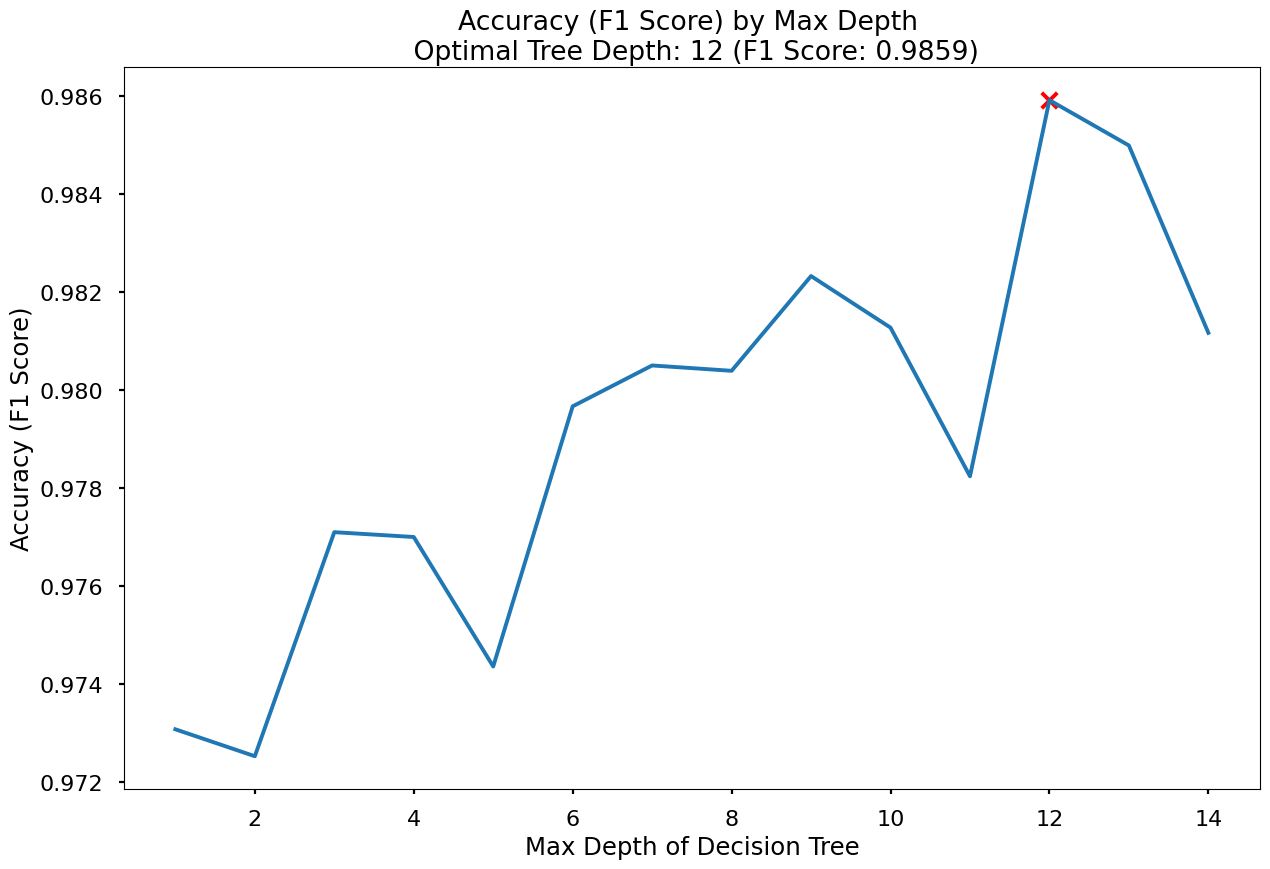

In [421]:
# finding the best max_depth

# set up range for search, and empty list to append accuracy scores to
max_depth_list = list(range(1,15))
accuracy_scores = []

# loop through each possible depth, train and validate model, append test set f1-score
for depth in max_depth_list:
    
    dt = DecisionTreeClassifier(max_depth = depth, random_state = 42)
    dt.fit(X_train,y_train)
    y_pred = dt.predict(X_test)
    accuracy = f1_score(y_test,y_pred)
    accuracy_scores.append(accuracy)
    
# store max accuracy, and optimal depth    
max_accuracy = max(accuracy_scores)
max_accuracy_idx = accuracy_scores.index(max_accuracy)
optimal_depth = max_depth_list[max_accuracy_idx]

# plot accuracy by max depth
plt.plot(max_depth_list,accuracy_scores)
plt.scatter(optimal_depth, max_accuracy, marker = "x", color = "red")
plt.title(f"Accuracy (F1 Score) by Max Depth \n Optimal Tree Depth: {optimal_depth} (F1 Score: {round(max_accuracy,4)})")
plt.xlabel("Max Depth of Decision Tree")
plt.ylabel("Accuracy (F1 Score)")
plt.tight_layout()
plt.savefig('CP_8.jpg',bbox_inches='tight',dpi=150)
plt.show()

In the plot we can see that the maximum F1-Score on the test set is found when applying a max_depth value of 12 which takes our F1-Score up to 0.985

### Random Forest
We will again utlise the scikit-learn library within Python to model our data using a Random Forest. The code sections below are broken up into 4 key sections:

* Data Import
* Data Preprocessing
* Model Training
* Performance Assessment

In [149]:
# import required packages
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.inspection import permutation_importance

In [150]:
df = pd.read_sql(query, database)

In [151]:
df.head()

,loan_id,no_of_dependents,gender,education,self_employed,income_annum,income_annum_group_lacs,loan_amount,loan_amount_group,loan_term,...,cibil_score_category,residential_assets_value,residential_assets_value_group,commercial_assets_value,commercial_assets_value_group,luxury_assets_value,luxury_assets_value_group,bank_asset_value,bank_asset_value_group,loan_status
0,1,2,Male,Post Graduate,No,9600000.0,90 Lacs+,29900000.0,2.5-3,12,...,Excellent,2400000.0,0-0.5,17600000.0,1.5-2,22700000.0,2-2.5,8000000.0,0.5-1,Approved
1,2,0,Male,Post Graduate,Yes,4100000.0,40-50 Lacs,12200000.0,1-1.5,8,...,Low,2700000.0,0-0.5,2200000.0,0-0.5,8800000.0,0.5-1,3300000.0,0-0.5,Rejected
2,3,3,Male,Post Graduate,No,9100000.0,90 Lacs+,29700000.0,2.5-3,20,...,Low,7100000.0,0.5-1,4500000.0,0-0.5,33300000.0,3-3.5,12800000.0,1-1.5,Rejected
3,4,3,Female,Post Graduate,No,8200000.0,80-90 Lacs,30700000.0,3-3.5,8,...,Low,18200000.0,1.5-2,3300000.0,0-0.5,23300000.0,2-2.5,7900000.0,0.5-1,Rejected
4,5,5,Male,Post Graduate,Yes,9800000.0,90 Lacs+,24200000.0,2-2.5,20,...,Low,12400000.0,1-1.5,8200000.0,0.5-1,29400000.0,2.5-3,5000000.0,0.5-1,Rejected


In [152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   loan_id                         4269 non-null   int64  
 1   no_of_dependents                4269 non-null   int64  
 2   gender                          4269 non-null   object 
 3   education                       4269 non-null   object 
 4   self_employed                   4269 non-null   object 
 5   income_annum                    4269 non-null   float64
 6   income_annum_group_lacs         4269 non-null   object 
 7   loan_amount                     4269 non-null   float64
 8   loan_amount_group               4269 non-null   object 
 9   loan_term                       4269 non-null   int64  
 10  cibil_score                     4269 non-null   int64  
 11  cibil_score_category            4269 non-null   object 
 12  residential_assets_value        42

In [153]:
df.columns

Index(['loan_id', 'no_of_dependents', 'gender', 'education', 'self_employed',
       'income_annum', 'income_annum_group_lacs', 'loan_amount',
       'loan_amount_group', 'loan_term', 'cibil_score', 'cibil_score_category',
       'residential_assets_value', 'residential_assets_value_group',
       'commercial_assets_value', 'commercial_assets_value_group',
       'luxury_assets_value', 'luxury_assets_value_group', 'bank_asset_value',
       'bank_asset_value_group', 'loan_status'],
      dtype='object')

In [154]:
df_model = df[['no_of_dependents', 'gender', 'education', 'self_employed','income_annum', 'loan_amount',     
               'loan_term', 'cibil_score','residential_assets_value','commercial_assets_value', 
               'luxury_assets_value',  'bank_asset_value', 'loan_status']]

In [155]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   no_of_dependents          4269 non-null   int64  
 1   gender                    4269 non-null   object 
 2   education                 4269 non-null   object 
 3   self_employed             4269 non-null   object 
 4   income_annum              4269 non-null   float64
 5   loan_amount               4269 non-null   float64
 6   loan_term                 4269 non-null   int64  
 7   cibil_score               4269 non-null   int64  
 8   residential_assets_value  4269 non-null   float64
 9   commercial_assets_value   4269 non-null   float64
 10  luxury_assets_value       4269 non-null   float64
 11  bank_asset_value          4269 non-null   float64
 12  loan_status               4269 non-null   object 
dtypes: float64(6), int64(3), object(4)
memory usage: 433.7+ KB


In [156]:
df_model["loan_status"]= df_model["loan_status"].map({"Approved":1,"Rejected":0})

In [157]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   no_of_dependents          4269 non-null   int64  
 1   gender                    4269 non-null   object 
 2   education                 4269 non-null   object 
 3   self_employed             4269 non-null   object 
 4   income_annum              4269 non-null   float64
 5   loan_amount               4269 non-null   float64
 6   loan_term                 4269 non-null   int64  
 7   cibil_score               4269 non-null   int64  
 8   residential_assets_value  4269 non-null   float64
 9   commercial_assets_value   4269 non-null   float64
 10  luxury_assets_value       4269 non-null   float64
 11  bank_asset_value          4269 non-null   float64
 12  loan_status               4269 non-null   int64  
dtypes: float64(6), int64(4), object(3)
memory usage: 433.7+ KB


In [158]:
# split data into X and y objects for modelling
X = df_model.drop(["loan_status"], axis = 1)
y = df_model["loan_status"]

# split out training & test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [159]:
# list of categorical variables that need encoding
categorical_vars = ["gender","education", "self_employed"]

# instantiate OHE class
one_hot_encoder = OneHotEncoder(sparse=False, drop = "first")

# apply OHE
X_train_encoded = one_hot_encoder.fit_transform(X_train[categorical_vars])
X_test_encoded = one_hot_encoder.transform(X_test[categorical_vars])

# extract feature names for encoded columns
encoder_feature_names = one_hot_encoder.get_feature_names_out(categorical_vars)

# turn objects back to pandas dataframe
X_train_encoded = pd.DataFrame(X_train_encoded, columns = encoder_feature_names)
X_train = pd.concat([X_train.reset_index(drop=True), X_train_encoded.reset_index(drop=True)], axis = 1)
X_train.drop(categorical_vars, axis = 1, inplace = True)

X_test_encoded = pd.DataFrame(X_test_encoded, columns = encoder_feature_names)
X_test = pd.concat([X_test.reset_index(drop=True), X_test_encoded.reset_index(drop=True)], axis = 1)
X_test.drop(categorical_vars, axis = 1, inplace = True)

In [160]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3415 entries, 0 to 3414
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   no_of_dependents          3415 non-null   int64  
 1   income_annum              3415 non-null   float64
 2   loan_amount               3415 non-null   float64
 3   loan_term                 3415 non-null   int64  
 4   cibil_score               3415 non-null   int64  
 5   residential_assets_value  3415 non-null   float64
 6   commercial_assets_value   3415 non-null   float64
 7   luxury_assets_value       3415 non-null   float64
 8   bank_asset_value          3415 non-null   float64
 9   gender_Male               3415 non-null   float64
 10  education_Not Graduate    3415 non-null   float64
 11  education_Post Graduate   3415 non-null   float64
 12  self_employed_Yes         3415 non-null   float64
dtypes: float64(10), int64(3)
memory usage: 347.0 KB


In [161]:

# instantiate our model object
rf = RandomForestClassifier(random_state = 42, n_estimators = 500, max_features = 5)

# fit our model using our training & test sets
rf.fit(X_train, y_train)


RandomForestClassifier(max_features=5, n_estimators=500, random_state=42)

In [162]:
# predict on the test set
y_pred_class = rf.predict(X_test)
y_pred_prob = rf.predict_proba(X_test)[:,1]

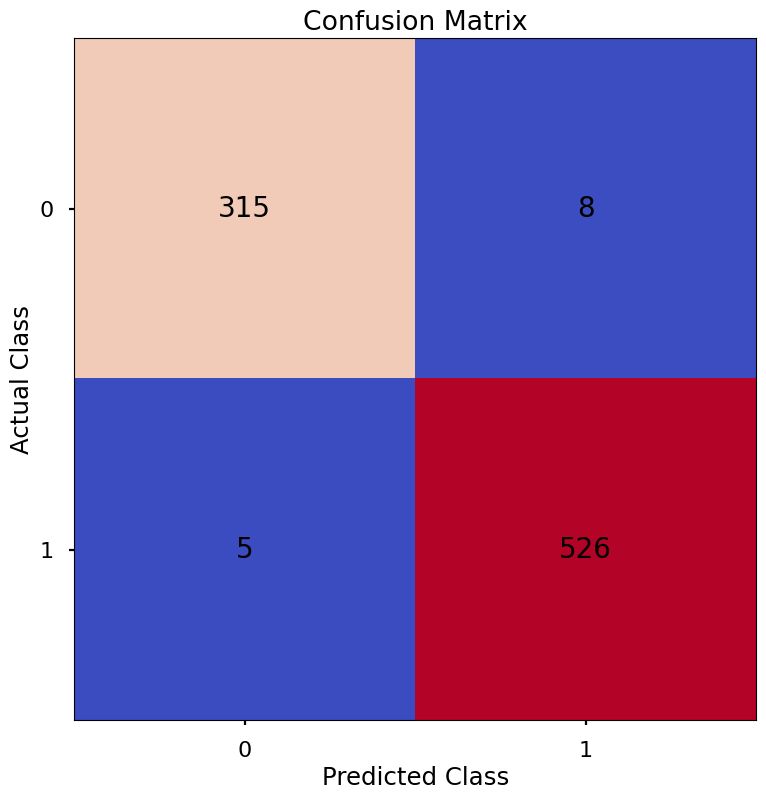

In [454]:
# create the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_class)

# plot the confusion matrix
plt.style.use("seaborn-poster")
plt.matshow(conf_matrix, cmap = "coolwarm")
plt.gca().xaxis.tick_bottom()
plt.title("Confusion Matrix")
plt.ylabel("Actual Class")
plt.xlabel("Predicted Class")
for (i, j), corr_value in np.ndenumerate(conf_matrix):
    plt.text(j, i, corr_value, ha = "center", va = "center", fontsize = 20)

plt.savefig('CP_9.jpg',bbox_inches='tight',dpi=150)
plt.show()

In [163]:
print('Accuracy:', '%.3f' % accuracy_score(y_test, y_pred_class))
print('Precision:', '%.3f' % precision_score(y_test, y_pred_class))
print('Recall:', '%.3f' % recall_score(y_test, y_pred_class))
print('F1 Score:', '%.3f' % f1_score(y_test, y_pred_class))

Accuracy: 0.985
Precision: 0.985
Recall: 0.991
F1 Score: 0.988


**Feature Importance**

Random Forests are an ensemble model, made up of many, many Decision Trees, each of which is different due to the randomness of the data being provided, and the random selection of input variables available at each potential split point.

Because of this, we end up with a powerful and robust model, but because of the random or different nature of all these Decision trees - the model gives us a unique insight into how important each of our input variables are to the overall model.

As we’re using random samples of data, and input variables for each Decision Tree - there are many scenarios where certain input variables are being held back and this enables us a way to compare how accurate the models predictions are if that variable is or isn’t present.

So, at a high level, in a Random Forest we can measure importance by asking How much would accuracy decrease if a specific input variable was removed or randomised?

If this decrease in performance, or accuracy, is large, then we’d deem that input variable to be quite important, and if we see only a small decrease in accuracy, then we’d conclude that the variable is of less importance.

At a high level, there are two common ways to tackle this. The first, often just called Feature Importance is where we find all nodes in the Decision Trees of the forest where a particular input variable is used to split the data and assess what the gini impurity score (for a Classification problem) was before the split was made, and compare this to the gini impurity score after the split was made. We can take the average of these improvements across all Decision Trees in the Random Forest to get a score that tells us how much better we’re making the model by using that input variable.

If we do this for each of our input variables, we can compare these scores and understand which is adding the most value to the predictive power of the model!

The other approach, often called Permutation Importance cleverly uses some data that has gone unused at when random samples are selected for each Decision Tree (this stage is called “bootstrap sampling” or “bootstrapping”)

These observations that were not randomly selected for each Decision Tree are known as Out of Bag observations and these can be used for testing the accuracy of each particular Decision Tree.

For each Decision Tree, all of the Out of Bag observations are gathered and then passed through. Once all of these observations have been run through the Decision Tree, we obtain a classification accuracy score for these predictions.

In order to understand the importance, we randomise the values within one of the input variables - a process that essentially destroys any relationship that might exist between that input variable and the output variable - and run that updated data through the Decision Tree again, obtaining a second accuracy score. The difference between the original accuracy and the new accuracy gives us a view on how important that particular variable is for predicting the output.

Permutation Importance is often preferred over Feature Importance which can at times inflate the importance of numerical features. Both are useful, and in most cases will give fairly similar results.

Let’s put them both in place, and plot the results…

<Axes: >

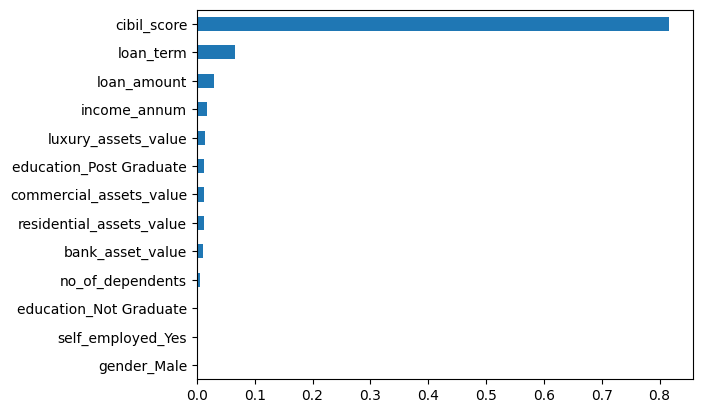

In [166]:
importances = rf.feature_importances_
forest_importances = pd.Series(importances, index=X_train.columns)

# Sort the Series by importance in descending order
forest_importances_sorted = forest_importances.sort_values()

fig, ax = plt.subplots()
forest_importances_sorted.plot.barh(ax=ax)

In [125]:
# calculate feature importance
feature_importance = pd.DataFrame(rf.feature_importances_)
feature_names = pd.DataFrame(X_train.columns)
feature_importance_summary = pd.concat([feature_names,feature_importance], axis = 1)
feature_importance_summary.columns = ["input_variable","feature_importance"]
feature_importance_summary.sort_values(by = "feature_importance",ascending=False, inplace = True)
feature_importance_summary


,input_variable,feature_importance
4,cibil_score,0.816747
3,loan_term,0.065288
2,loan_amount,0.029542
1,income_annum,0.016843
7,luxury_assets_value,0.013493
11,education_Post Graduate,0.012536
6,commercial_assets_value,0.012152
5,residential_assets_value,0.012024
8,bank_asset_value,0.009939
0,no_of_dependents,0.005875


In [126]:
# calculate permutation importance
result = permutation_importance(rf, X_test, y_test, n_repeats = 10, random_state = 42)
permutation_importance = pd.DataFrame(result["importances_mean"])
feature_names = pd.DataFrame(X_train.columns)
permutation_importance_summary = pd.concat([feature_names,permutation_importance], axis = 1)
permutation_importance_summary.columns = ["input_variable","permutation_importance"]
permutation_importance_summary.sort_values(by = "permutation_importance",ascending=False, inplace = True)
permutation_importance_summary


,input_variable,permutation_importance
4,cibil_score,0.422600
3,loan_term,0.047658
2,loan_amount,0.016628
1,income_annum,0.013466
7,luxury_assets_value,0.006089
6,commercial_assets_value,0.004450
8,bank_asset_value,0.001874
12,self_employed_Yes,0.001639
0,no_of_dependents,0.001522
5,residential_assets_value,0.000703


#### K Nearest Neighbours
We utlise the scikit-learn library within Python to model our data using KNN. The code sections below are broken up into 5 key sections:

* Data Import
* Data Preprocessing
* Model Training
* Performance Assessment
* Optimal Value For K

In [140]:
# import required packages
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.feature_selection import RFECV

In [141]:
df = pd.read_sql(query, database)

In [142]:
df.head()

,loan_id,no_of_dependents,gender,education,self_employed,income_annum,income_annum_group_lacs,loan_amount,loan_amount_group,loan_term,...,cibil_score_category,residential_assets_value,residential_assets_value_group,commercial_assets_value,commercial_assets_value_group,luxury_assets_value,luxury_assets_value_group,bank_asset_value,bank_asset_value_group,loan_status
0,1,2,Male,Post Graduate,No,9600000.0,90 Lacs+,29900000.0,2.5-3,12,...,Excellent,2400000.0,0-0.5,17600000.0,1.5-2,22700000.0,2-2.5,8000000.0,0.5-1,Approved
1,2,0,Male,Post Graduate,Yes,4100000.0,40-50 Lacs,12200000.0,1-1.5,8,...,Low,2700000.0,0-0.5,2200000.0,0-0.5,8800000.0,0.5-1,3300000.0,0-0.5,Rejected
2,3,3,Male,Post Graduate,No,9100000.0,90 Lacs+,29700000.0,2.5-3,20,...,Low,7100000.0,0.5-1,4500000.0,0-0.5,33300000.0,3-3.5,12800000.0,1-1.5,Rejected
3,4,3,Female,Post Graduate,No,8200000.0,80-90 Lacs,30700000.0,3-3.5,8,...,Low,18200000.0,1.5-2,3300000.0,0-0.5,23300000.0,2-2.5,7900000.0,0.5-1,Rejected
4,5,5,Male,Post Graduate,Yes,9800000.0,90 Lacs+,24200000.0,2-2.5,20,...,Low,12400000.0,1-1.5,8200000.0,0.5-1,29400000.0,2.5-3,5000000.0,0.5-1,Rejected


In [143]:
df.columns

Index(['loan_id', 'no_of_dependents', 'gender', 'education', 'self_employed',
       'income_annum', 'income_annum_group_lacs', 'loan_amount',
       'loan_amount_group', 'loan_term', 'cibil_score', 'cibil_score_category',
       'residential_assets_value', 'residential_assets_value_group',
       'commercial_assets_value', 'commercial_assets_value_group',
       'luxury_assets_value', 'luxury_assets_value_group', 'bank_asset_value',
       'bank_asset_value_group', 'loan_status'],
      dtype='object')

In [144]:
df_model = df[['no_of_dependents', 'gender', 'education', 'self_employed','income_annum', 'loan_amount',     
               'loan_term', 'cibil_score','residential_assets_value','commercial_assets_value', 
               'luxury_assets_value',  'bank_asset_value', 'loan_status']]

In [145]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   no_of_dependents          4269 non-null   int64  
 1   gender                    4269 non-null   object 
 2   education                 4269 non-null   object 
 3   self_employed             4269 non-null   object 
 4   income_annum              4269 non-null   float64
 5   loan_amount               4269 non-null   float64
 6   loan_term                 4269 non-null   int64  
 7   cibil_score               4269 non-null   int64  
 8   residential_assets_value  4269 non-null   float64
 9   commercial_assets_value   4269 non-null   float64
 10  luxury_assets_value       4269 non-null   float64
 11  bank_asset_value          4269 non-null   float64
 12  loan_status               4269 non-null   object 
dtypes: float64(6), int64(3), object(4)
memory usage: 433.7+ KB


In [146]:
df_model["loan_status"]= df_model["loan_status"].map({"Approved":1,"Rejected":0})

In [147]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   no_of_dependents          4269 non-null   int64  
 1   gender                    4269 non-null   object 
 2   education                 4269 non-null   object 
 3   self_employed             4269 non-null   object 
 4   income_annum              4269 non-null   float64
 5   loan_amount               4269 non-null   float64
 6   loan_term                 4269 non-null   int64  
 7   cibil_score               4269 non-null   int64  
 8   residential_assets_value  4269 non-null   float64
 9   commercial_assets_value   4269 non-null   float64
 10  luxury_assets_value       4269 non-null   float64
 11  bank_asset_value          4269 non-null   float64
 12  loan_status               4269 non-null   int64  
dtypes: float64(6), int64(4), object(3)
memory usage: 433.7+ KB


In [148]:
df_model.describe()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
count,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03,4269.000000
mean,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06,0.622160
std,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06,0.484904
min,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00,0.000000
25%,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06,0.000000
50%,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06,1.000000
75%,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06,1.000000
max,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07,1.000000


In [ ]:
outlier_investigation = data_for_model.describe()
outlier_columns = ["distance_from_store", "total_sales", "total_items"]

# boxplot approach
for column in outlier_columns:
    
    lower_quartile = df_model[column].quantile(0.25)
    upper_quartile = df_model[column].quantile(0.75)
    iqr = upper_quartile - lower_quartile
    iqr_extended = iqr * 2
    min_border = lower_quartile - iqr_extended
    max_border = upper_quartile + iqr_extended
    
    outliers = df_model[(df_model[column] < min_border) | (df_model[column] > max_border)].index
    print(f"{len(outliers)} outliers detected in column {column}")
    
    df_model.drop(outliers, inplace = True)

In [135]:
# split data into X and y objects for modelling
X = df_model.drop(["loan_status"], axis = 1)
y = df_model["loan_status"]

# split out training & test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [136]:
# list of categorical variables that need encoding
categorical_vars = ["gender","education", "self_employed"]

# instantiate OHE class
one_hot_encoder = OneHotEncoder(sparse=False, drop = "first")

# apply OHE
X_train_encoded = one_hot_encoder.fit_transform(X_train[categorical_vars])
X_test_encoded = one_hot_encoder.transform(X_test[categorical_vars])

# extract feature names for encoded columns
encoder_feature_names = one_hot_encoder.get_feature_names_out(categorical_vars)

# turn objects back to pandas dataframe
X_train_encoded = pd.DataFrame(X_train_encoded, columns = encoder_feature_names)
X_train = pd.concat([X_train.reset_index(drop=True), X_train_encoded.reset_index(drop=True)], axis = 1)
X_train.drop(categorical_vars, axis = 1, inplace = True)

X_test_encoded = pd.DataFrame(X_test_encoded, columns = encoder_feature_names)
X_test = pd.concat([X_test.reset_index(drop=True), X_test_encoded.reset_index(drop=True)], axis = 1)
X_test.drop(categorical_vars, axis = 1, inplace = True)

In [137]:
# create our scaler object
scale_norm = MinMaxScaler()

# normalise the training set (using fit_transform)
X_train = pd.DataFrame(scale_norm.fit_transform(X_train), columns = X_train.columns)

# normalise the test set (using transform only)
X_test = pd.DataFrame(scale_norm.transform(X_test), columns = X_test.columns)

In [138]:

# instantiate RFECV & the model type to be utilised
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(random_state = 42)
feature_selector = RFECV(clf)

# fit RFECV onto our training & test data
fit = feature_selector.fit(X_train,y_train)

# extract & print the optimal number of features
optimal_feature_count = feature_selector.n_features_
print(f"Optimal number of features: {optimal_feature_count}")

# limit our training & test sets to only include the selected variables
X_train_features = X_train.loc[:, feature_selector.get_support()]

Optimal number of features: 4


In [139]:
X_train_features.columns

Index(['income_annum', 'loan_amount', 'loan_term', 'cibil_score'], dtype='object')

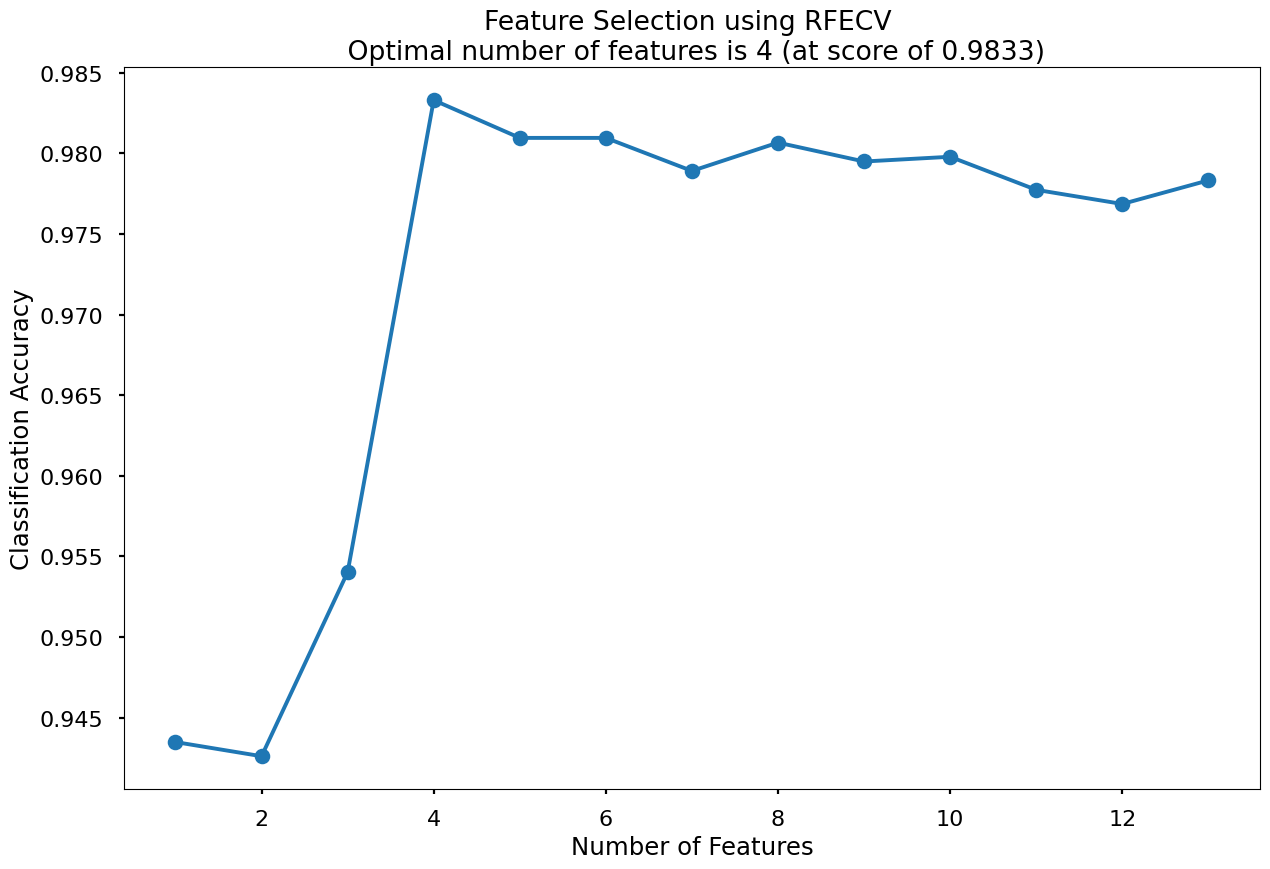

In [470]:
plt.style.use('seaborn-poster')
plt.plot(range(1, len(fit.cv_results_['mean_test_score']) + 1), fit.cv_results_['mean_test_score'], marker = "o")
plt.ylabel("Classification Accuracy")
plt.xlabel("Number of Features")
plt.title(f"Feature Selection using RFECV \n Optimal number of features is {optimal_feature_count} (at score of {round(max(fit.cv_results_['mean_test_score']),4)})")
plt.tight_layout()
plt.savefig('CP_10.jpg',bbox_inches='tight',dpi=150)
plt.show()

This creates the below plot, which shows us that the highest cross-validated classification accuracy (0.9833) is when we include 4 of our original input variables - although there isn’t much difference in predictive performance between using 3 variables through to 13 variables - and this syncs with what we saw in the Random Forest section above where only three of the input variables scored highly when assessing Feature Importance & Permutation Importance.


In [471]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3415 entries, 0 to 3414
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   no_of_dependents          3415 non-null   float64
 1   income_annum              3415 non-null   float64
 2   loan_amount               3415 non-null   float64
 3   loan_term                 3415 non-null   float64
 4   cibil_score               3415 non-null   float64
 5   residential_assets_value  3415 non-null   float64
 6   commercial_assets_value   3415 non-null   float64
 7   luxury_assets_value       3415 non-null   float64
 8   bank_asset_value          3415 non-null   float64
 9   gender_Male               3415 non-null   float64
 10  education_Not Graduate    3415 non-null   float64
 11  education_Post Graduate   3415 non-null   float64
 12  self_employed_Yes         3415 non-null   float64
dtypes: float64(13)
memory usage: 347.0 KB


In [474]:

# instantiate our model object
knn = KNeighborsClassifier()

# fit our model using our training & test sets
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [475]:
# predict on the test set
y_pred_class = knn.predict(X_test)
y_pred_prob = knn.predict_proba(X_test)[:,1]

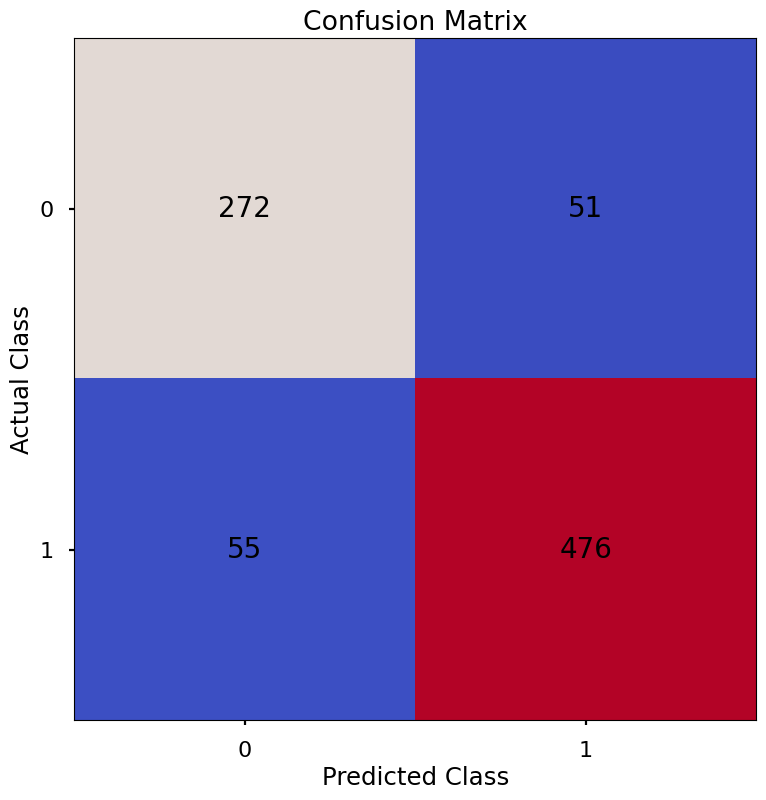

In [476]:
# create the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_class)

# plot the confusion matrix
plt.style.use("seaborn-poster")
plt.matshow(conf_matrix, cmap = "coolwarm")
plt.gca().xaxis.tick_bottom()
plt.title("Confusion Matrix")
plt.ylabel("Actual Class")
plt.xlabel("Predicted Class")
for (i, j), corr_value in np.ndenumerate(conf_matrix):
    plt.text(j, i, corr_value, ha = "center", va = "center", fontsize = 20)
plt.savefig('CP_11.jpg',bbox_inches='tight',dpi=150)
plt.show()

In [477]:
print('Accuracy:', '%.3f' % accuracy_score(y_test, y_pred_class))
print('Precision:', '%.3f' % precision_score(y_test, y_pred_class))
print('Recall:', '%.3f' % recall_score(y_test, y_pred_class))
print('F1 Score:', '%.3f' % f1_score(y_test, y_pred_class))

Accuracy: 0.876
Precision: 0.903
Recall: 0.896
F1 Score: 0.900


* Accuracy: We have an accuracy of around 0.876. This suggests that our model is correctly classifying around 90.9% of instances.

* Precision: Precision measures how many of the predicted positive instances are actually positive. With a precision of around 0.903, it means that about 90.3% of the instances predicted as positive by our model are truly positive.

* Recall: Recall, also known as sensitivity or true positive rate, indicates how many of the actual positive instances our model is capturing. With a recall of around 0.896, it means that our model is correctly identifying about 89.6% of the actual positive instances.

* F1 Score: The F1 score is the harmonic mean of precision and recall and provides a balanced view of a model's performance. With an F1 score of around 0.900, it indicates that the model is achieving a balanced trade-off between precision and recall.

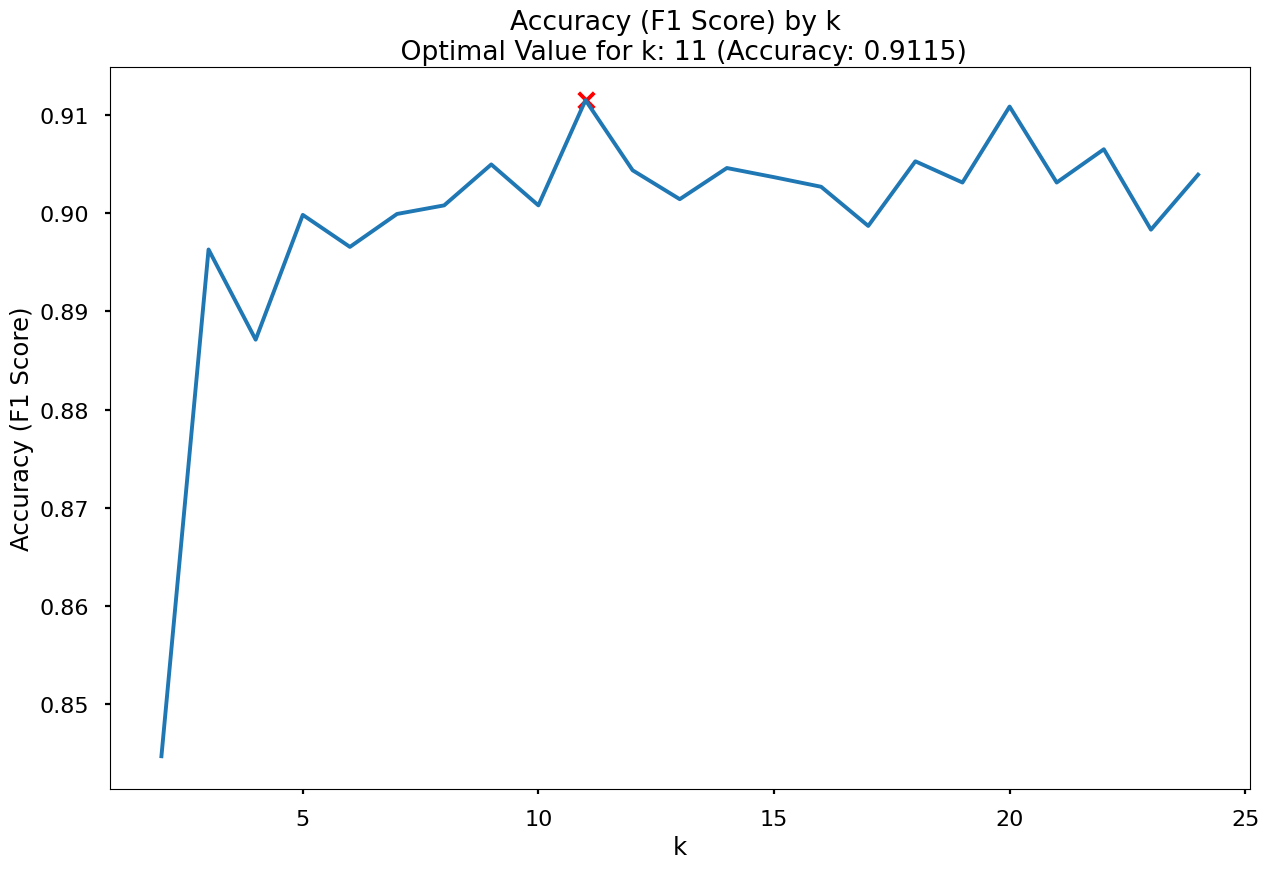

In [478]:

# set up range for search, and empty list to append accuracy scores to
k_list = list(range(2,25))
accuracy_scores = []

# loop through each possible value of k, train and validate model, append test set f1-score
for k in k_list:
    
    clf = KNeighborsClassifier(n_neighbors = k)
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = f1_score(y_test,y_pred)
    accuracy_scores.append(accuracy)
    
# store max accuracy, and optimal k value    
max_accuracy = max(accuracy_scores)
max_accuracy_idx = accuracy_scores.index(max_accuracy)
optimal_k_value = k_list[max_accuracy_idx]

# plot accuracy by max depth
plt.plot(k_list,accuracy_scores)
plt.scatter(optimal_k_value, max_accuracy, marker = "x", color = "red")
plt.title(f"Accuracy (F1 Score) by k \n Optimal Value for k: {optimal_k_value} (Accuracy: {round(max_accuracy,4)})")
plt.xlabel("k")
plt.ylabel("Accuracy (F1 Score)")
plt.tight_layout()
plt.savefig('CP_12.jpg',bbox_inches='tight',dpi=150)
plt.show()

In the plot we can see that the maximum F1-Score on the test set is found when applying a k value of 11. We started with k=5, so we need to change!

**Modelling Summary**

A secondary goal was to understand what the drivers for this are, so the client can get closer to the customers that need or want this service, and enhance their messaging.

Based upon these, the chosen the model is the **Random Forest** as it was a) the most consistently performant on the test set across classication accuracy, precision, recall, and f1-score, and b) the feature importance and permutation importance allows the client an understanding of the key drivers behind delivery club signups.


Metric 1: **Classification Accuracy**


* Random Forest = 0.985
* Decision Tree = 0.968
* Logistic Regression = 0.917
* KNN = 0.876


Metric 2: **Precision**


* Random Forest = 0.985
* Decision Tree = 0.983
* Logistic Regression = 0.921
* KNN = 0.903

Metric 3: **Recall**


* Random Forest = 0.991
* Decision Tree = 0.966
* Logistic Regression = 0.947
* KNN = 0.896

Metric 4: **F1 Score**


* Random Forest = 0.988
* Decision Tree = 0.974
* Logistic Regression = 0.934
* KNN = 0.900